In [35]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('cleaned_ffod_delivery_times.csv')


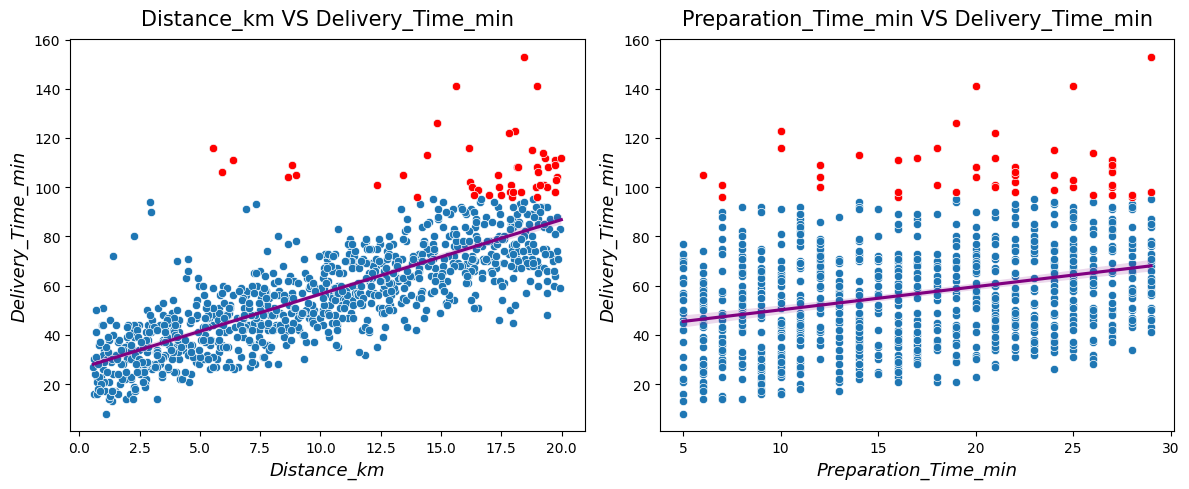

In [36]:
x_cols=['Distance_km','Preparation_Time_min']
y = 'Delivery_Time_min'

fig,ax = plt.subplots(1,2,figsize=(12,5))
for ax , col in zip(ax,x_cols):
    sns.scatterplot(data=df,x=col,y=y,ax=ax)
    ax.set_title(f'{col} VS {y}',fontsize=15,pad=10)
    sns.regplot(color='purple',ax=ax,x=col,y=y,data=df,scatter=False)
    outlires=df[df[y]>df[y].quantile(0.95)]
    sns.scatterplot(data=outlires,x=col,y=y,color='red',ax=ax)
    ax.set_xlabel(col,fontsize=13,fontstyle='italic')
    ax.set_ylabel(y,fontsize=13,fontstyle='italic')
plt.tight_layout()



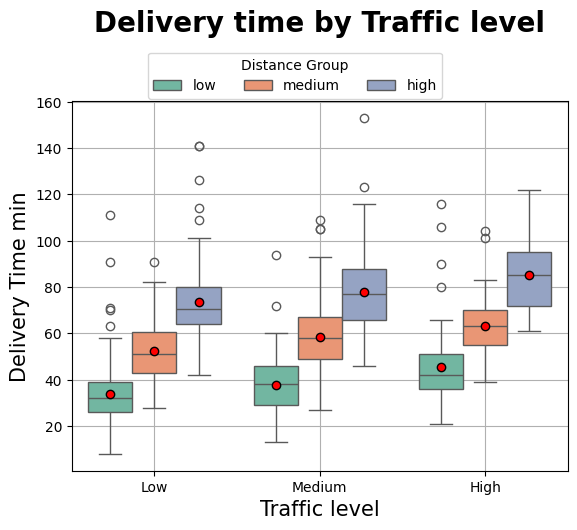

In [37]:
df['distance_group']=pd.cut(df['Distance_km'],bins=3,labels=['low','medium','high'])
sns.boxplot(
    data=df,x=df['Traffic_Level'],y=df['Delivery_Time_min'],palette='Set2',
    showmeans=True,
    hue=df['distance_group'],
    meanprops={
    "marker":"o",             
    "markerfacecolor":"red",  
    "markeredgecolor":"black" 
}
)
plt.grid(True)
plt.title('Delivery time by Traffic level',fontweight='bold',pad=50,fontsize=20)
plt.xlabel('Traffic level',fontsize=15)
plt.ylabel('Delivery Time min',fontsize=15)
plt.legend(title='Distance Group', loc='upper center',bbox_to_anchor=(0.45, 1.15), ncol=3)

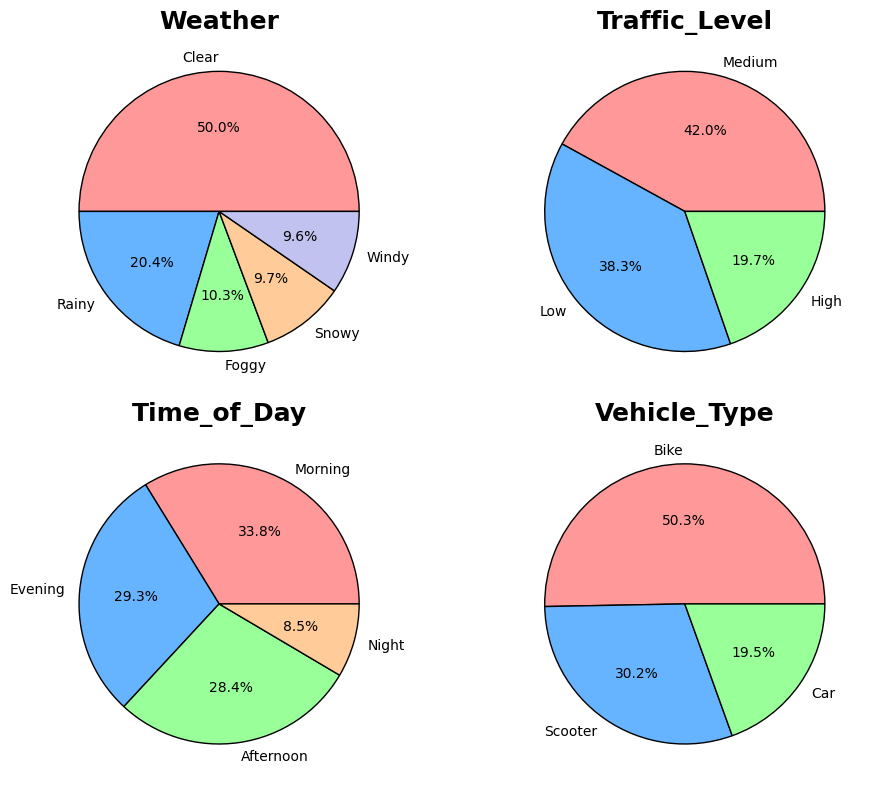

In [38]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
chart=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
ax=ax.flatten()
for i,col in enumerate(chart):
    data=df[col].value_counts()
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']
    ax[i].pie(data,labels=data.index,autopct='%1.1f%%',colors=colors,wedgeprops={'edgecolor':'black'})
    ax[i].set_title(col,fontsize=18,fontweight='bold')
    

plt.tight_layout()

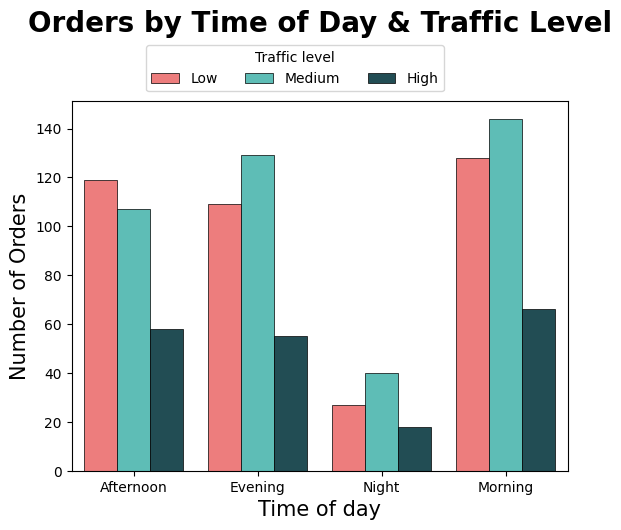

In [39]:
sns.countplot(x='Time_of_Day', hue='Traffic_Level', data=df, palette=['#ff6b6b', '#4ecdc4', '#1a535c'],
              edgecolor='black',linewidth=0.5)
plt.ylabel('Number of Orders',fontsize=15)
plt.xlabel('Time of day',fontsize=15)
plt.title('Orders by Time of Day & Traffic Level',pad=50,fontsize=20,fontweight='bold')
plt.legend(loc='upper center',title='Traffic level',ncol=3,bbox_to_anchor=(0.45 ,1.17));

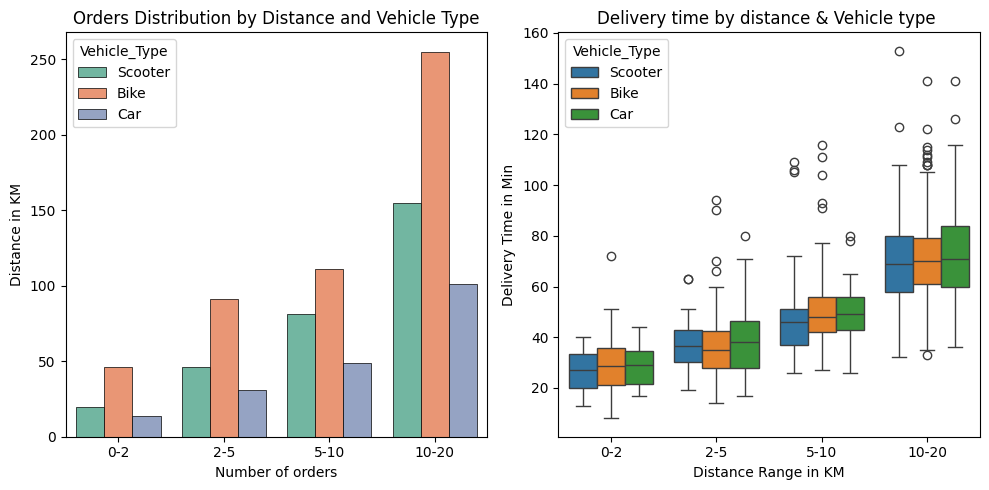

In [40]:
bins = [0, 2, 5, 10, 20] 
labels=['0-2','2-5','5-10','10-20']
df['Distance_bin']=pd.cut(df['Distance_km'],bins=bins,labels=labels)

fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.countplot(
    edgecolor='black',
    linewidth=0.5,
    ax=ax[0],
    data=df,
    x='Distance_bin',hue='Vehicle_Type',palette='Set2'
)
ax[0].set_xlabel('Number of orders')
ax[0].set_ylabel('Distance in KM')
ax[0].set_title('Orders Distribution by Distance and Vehicle Type')

sns.boxplot(ax=ax[1],data=df,x='Distance_bin',y='Delivery_Time_min',hue='Vehicle_Type')
ax[1].set_xlabel('Distance Range in KM')
ax[1].set_ylabel('Delivery Time in Min')
ax[1].set_title('Delivery time by distance & Vehicle type ')
plt.tight_layout()

C:\Users\wardo\AppData\Local\Temp\ipykernel_22608\3971937358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(


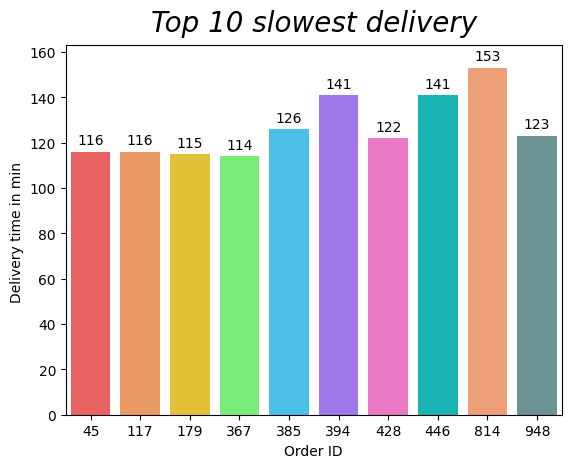

In [44]:
worst = df.sort_values(by='Delivery_Time_min',ascending=False).head(10)
colors = ['#ff4d4d','#ff944d','#ffd11a','#66ff66','#33ccff',
          '#9966ff','#ff66cc','#00cccc','#ff9966','#669999']
ax=sns.barplot(
    data=worst,x='Order_ID',y='Delivery_Time_min',
    palette=colors
)
for container in ax.containers:
    ax.bar_label(container,padding=3)
plt.xlabel('Order ID')
plt.ylabel('Delivery time in min ')
plt.ylim(0,worst['Delivery_Time_min'].max()+10)
plt.title('Top 10 slowest delivery' , fontsize=20,fontstyle='italic',pad=10);